# EDA

In [1]:
train_size = 0.85

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [4]:
df = data.copy()
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[us]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  str           
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 1.1 MB


type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


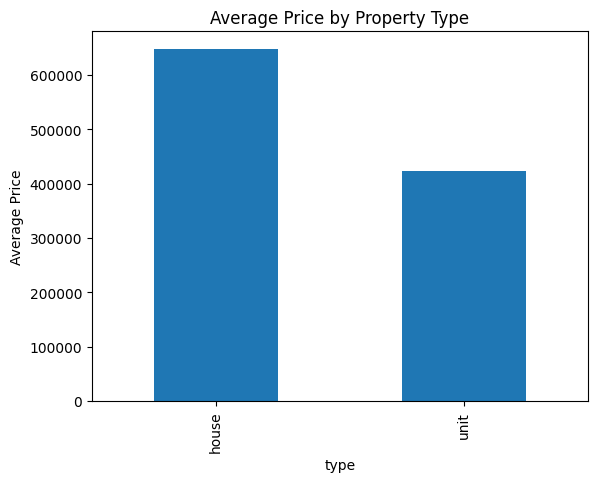

In [6]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.show()

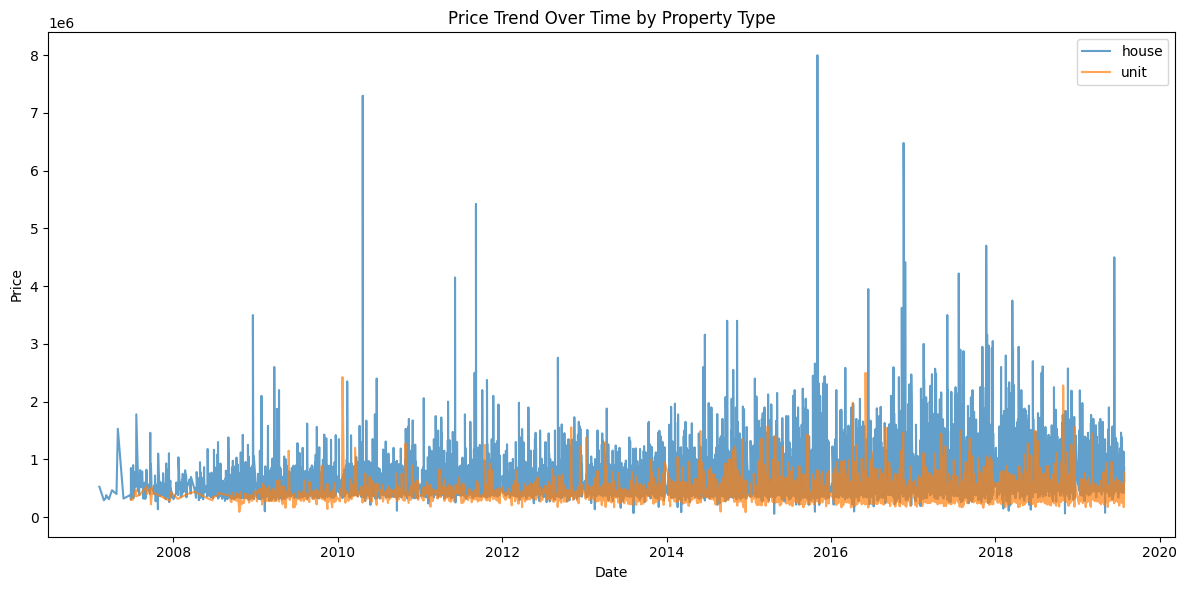

In [7]:
# plot the trend of mean price over time differenciating between houses and flats
def plot_price_house_flat(df):
    plt.figure(figsize=(12, 6))
    for property_type in df['type'].unique():
        subset = df[df['type'] == property_type]
        plt.plot(subset['date'], subset['price'], label=property_type, alpha=0.7)
    plt.title('Price Trend Over Time by Property Type')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_price_house_flat(df)

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


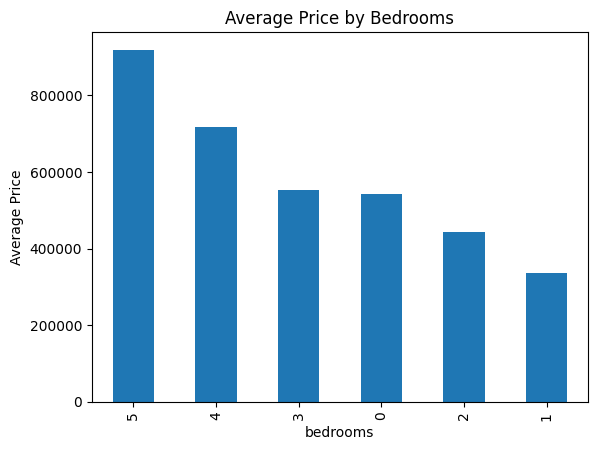

In [8]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

# MISSING VALUES

The number of bedrooms 0 can be considered as missing values, as it is unlikely that a property would have zero bedrooms. It is possible that these entries were either not recorded correctly. To handle these missing values, we can either impute them with a reasonable value (such as the median number of bedrooms for that property type) or we can choose to drop those rows from the dataset if they are not significant in number.

In [9]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

def imputer_pipeline(df):

    df2 = df.copy()

    df2['bedrooms'] = df2['bedrooms'].replace(0,np.nan)

    le = LabelEncoder()
    df2['type_encoded'] = le.fit_transform(df2['type'])

    features = ['price', 'type_encoded', 'bedrooms']
    X = df2[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_imputed = imputer.fit_transform(X_scaled)
    X_unscaled = scaler.inverse_transform(X_imputed)
    df2['bedrooms'] = X_unscaled[:,2]

    df2['bedrooms'] = df2['bedrooms'].round().astype(int)
    df2['bedrooms'] = df2['bedrooms'].clip(lower=1, upper=5)
    df2['bedrooms'].value_counts()

    return df2

In [10]:
#print the different values that bedrooms assumes when type == 'unit'
print(df[df['type'] == 'unit']['bedrooms'].unique())

[2 3 1 0 4 5]


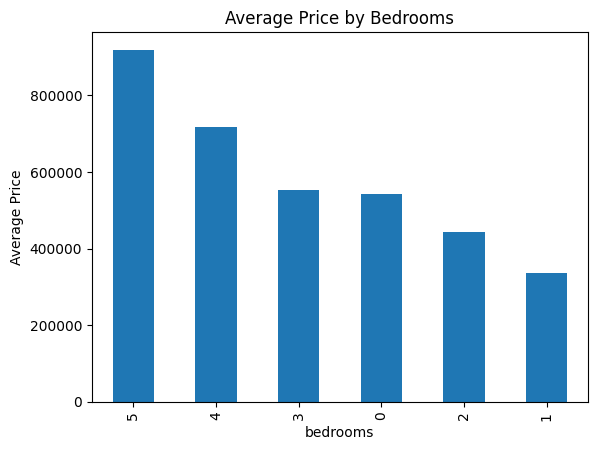

In [11]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

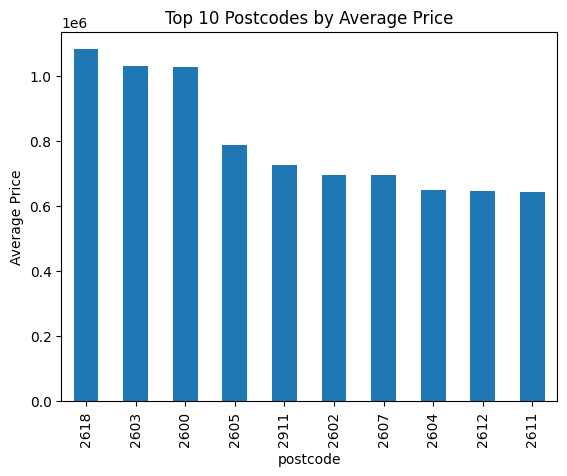

In [12]:
avg_price_by_postcode = df.groupby('postcode')['price'].mean().sort_values(ascending=False).head(10)

avg_price_by_postcode.plot(kind='bar', title='Top 10 Postcodes by Average Price')
plt.ylabel('Average Price')
plt.show()

In [13]:
df.columns


Index(['date', 'postcode', 'price', 'type', 'bedrooms'], dtype='str')

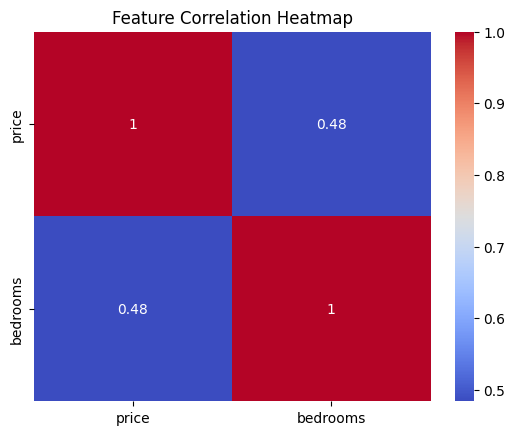

In [14]:
numeric_features = ['price', 'bedrooms']
sns.heatmap(df[numeric_features].corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The fact that the correlation between price and bedrooms is 0.49 suggests that there is a moderate positive relationship between the two variables. This means that, in general, as the number of bedrooms increases, the price tends to increase as well. However, it is not a very strong correlation, indicating that there are other factors influencing the price of the properties besides just the number of bedrooms.

# OUTLIERS

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 1374


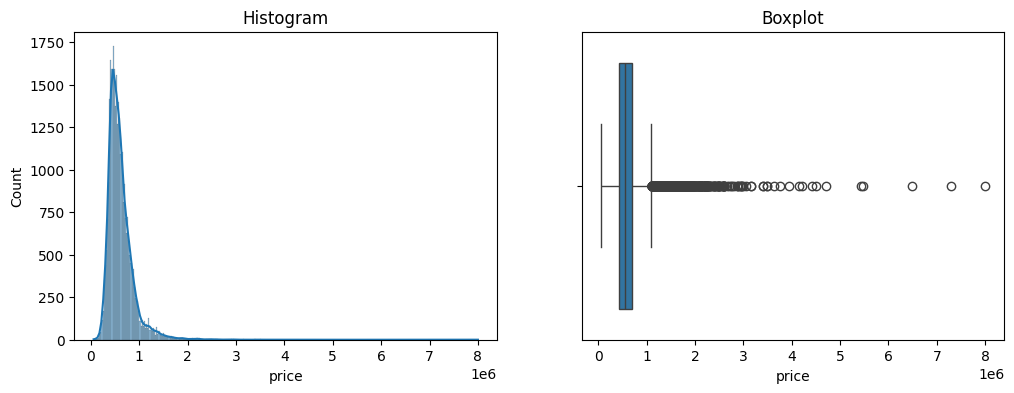

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_distribution(df, column):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    
    sns.histplot(df[column], kde=True, ax=ax[0])
    ax[0].set_title("Histogram")
    
    sns.boxplot(x=df[column], ax=ax[1])
    ax[1].set_title("Boxplot") # show outliers as points outside the box. outliers are considered as points outside the whiskers of the boxplot, which typically represent 1.5 times the interquartile range (IQR) from the first and third quartiles.
    
    plt.show()

visualize_distribution(df, 'price')

Since it's right skewed, we can apply a log transformation to the price variable to make it more normally distributed. This can help improve the performance of certain machine learning algorithms that assume normality in the data, such as linear regression. After applying the log transformation, we can visualize the distribution again to confirm that it has become more normal.

In [17]:
def plot_price_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], kde=True)
    plt.title('Distribution of Property Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def plot_price_trend(monthly):
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index, monthly['price'], color='lightgray', label='Original', linewidth=1.5)
    plt.plot(monthly.index, monthly['price_rolling'], color='blue', label='Smoothed', linewidth=2)
    plt.title('Mean Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Mean Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_monthly_trend(monthly_df):
    monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
        subplots=True, figsize=(10, 8), title='Monthly Trends')
    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.preprocessing import PowerTransformer

def pipeline(df, type_of_outlier, plotting=True):

    # we can try different types of handling right-skewed outliers: simply removing them, using log transformation, using power transformation.
    #the first option is to simply remove the outliers from the dataset, which can be done by filtering out the rows that contain outlier values based on a defined threshold (e.g., using the IQR method or Z-score method). This approach can help improve the performance of machine learning models by reducing the influence of extreme values, but it may also lead to loss of valuable information if not done carefully.
    #the second option is to apply a log transformation to the price variable, which can help reduce the impact of outliers and make the distribution more normal. This can be done by creating a new column in the dataframe that contains the log-transformed values of the price variable. This approach can be effective in improving the performance of certain machine learning algorithms that assume normality in the data, such as linear regression
    #the third option is to apply a power transformation to the price variable, which can also help reduce the impact of outliers

    if type_of_outlier == 'none':
        df_cleaned = df.copy()

    elif type_of_outlier == 'remove':
        Q1 = df['price'].quantile(0.25)
        Q3 = df['price'].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
        
    elif type_of_outlier == 'log_transform':
        df_cleaned = df.copy()
        df_cleaned['price'] = np.log(df_cleaned['price'])
    
    elif type_of_outlier == 'power_transform':
        df_cleaned = df.copy()
        pt = PowerTransformer(method='box-cox') # since price is positive, we can use box-cox transformation.  
        df_cleaned['price'] = pt.fit_transform(df_cleaned[['price']])

    #plot the distribution of the price variable after handling outliers
    if plotting:
        plot_price_distribution(df_cleaned)

    monthly = df_cleaned.resample('ME', on='date').agg({'price':'median'})
    monthly['price_rolling'] = monthly['price'].rolling(window=3, center=True).mean()

    #plot the original and smoothed median price over time
    if plotting:
        plot_price_trend(monthly)
    
    df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
    df_cleaned['month'] = df_cleaned['date'].dt.to_period('M')

    monthly_df = (df_cleaned.groupby('month').agg(
          price=('price', 'median'),
          house_ratio=('type', lambda x: (x == 'house').mean()),
          avg_bedrooms=('bedrooms', 'mean'),
          sales_count=('price', 'count')
     )
     .reset_index()
    )

    monthly_df['month'] = monthly_df['month'].dt.to_timestamp() # Convert Period to Timestamp for plotting (e.g. 2020-01-01 for January 2020)
    monthly_df.set_index('month', inplace=True)

    # if plotting:
    #     monthly_df.head()

    if plotting:
        plot_monthly_trend(monthly_df)

    return df_cleaned, monthly, monthly_df

The reason why we need house_ratio (house_ratio=('type', lambda x: (x == 'house').mean())) is to calculate the proportion of properties that are classified as 'house' within each month. This can provide insights into the distribution of property types over time and how it may relate to price trends. By including this ratio in our analysis, we can better understand the composition of the housing market and how it may influence median prices.

(29580, 5)
(29580, 6)


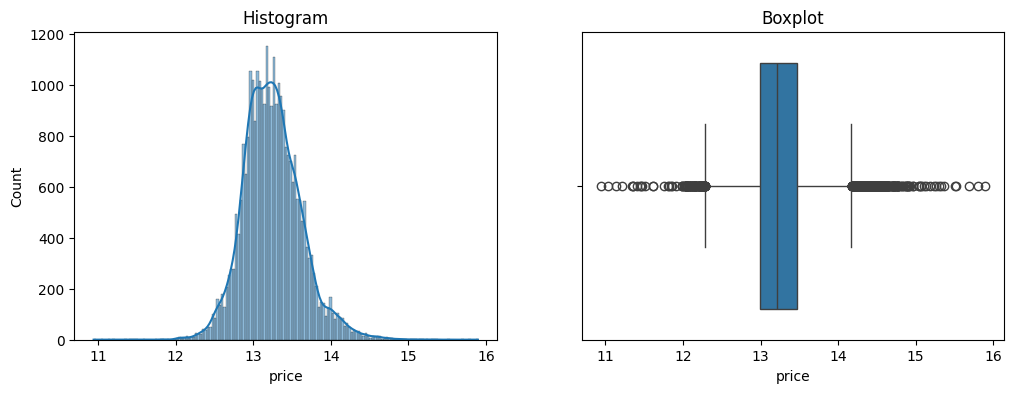

,price,house_ratio,avg_bedrooms,sales_count
month,,,,
2007-02-01,12.874395,1.000000,3.500000,2
2007-03-01,12.700769,1.000000,3.333333,3
2007-04-01,13.049793,1.000000,3.666667,3
2007-05-01,12.733577,1.000000,3.000000,2
2007-06-01,13.008398,0.833333,3.333333,6


In [29]:
print(df.shape)
df_cleaned,_,monthly_df = pipeline(df, type_of_outlier='log_transform', plotting=False)
print(df_cleaned.shape)
# df_cleaned, _, monthly_df = pipeline(df_cleaned, type_of_outlier='remove', plotting=True)
# print(df_cleaned.shape)
visualize_distribution(df_cleaned, 'price')
monthly_df.head()

In [22]:
#print average house price vs average unit price
avg_price_by_type = df.groupby('type')['price'].mean()
print(avg_price_by_type)

type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


# MEDIAN PRICE BY MONTH FORECAST WITH ML MODELS

### Random Forest Regressor


--- Random Forest | outlier method: none ---
Random Forest RMSE: $61,694.99


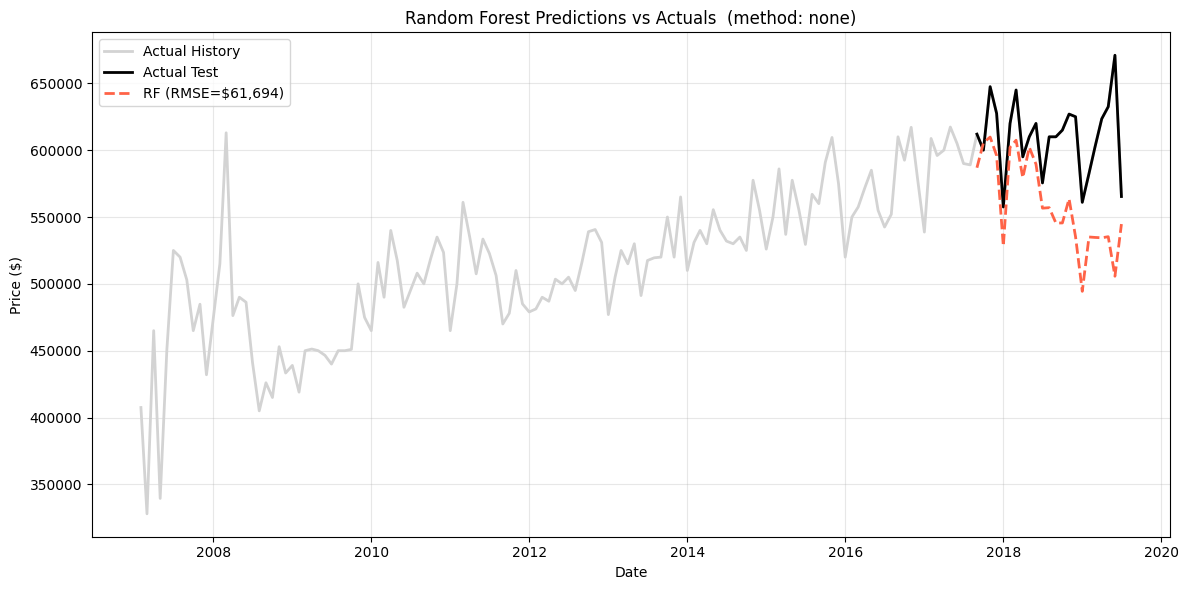

Feature importances:
sales_count     0.7930
avg_bedrooms    0.1219
house_ratio     0.0851
dtype: float64



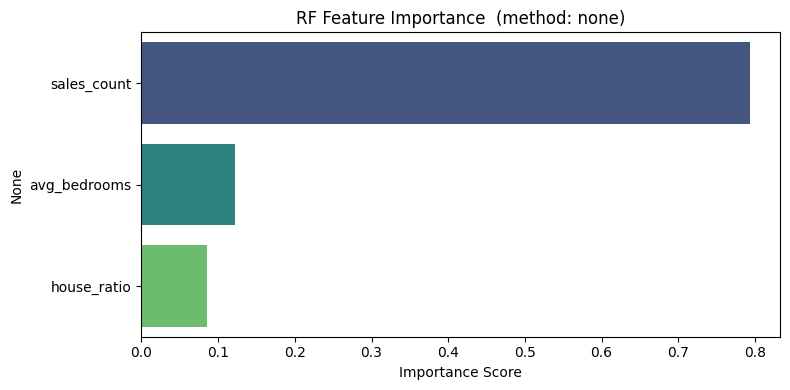

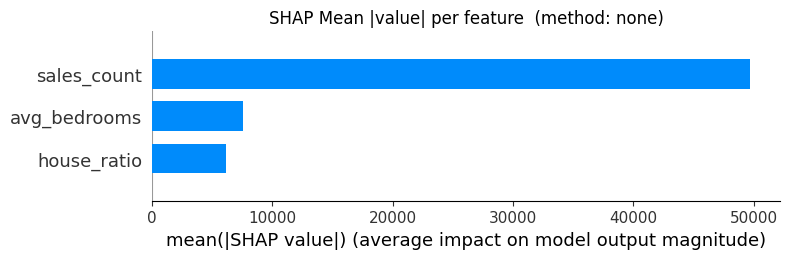

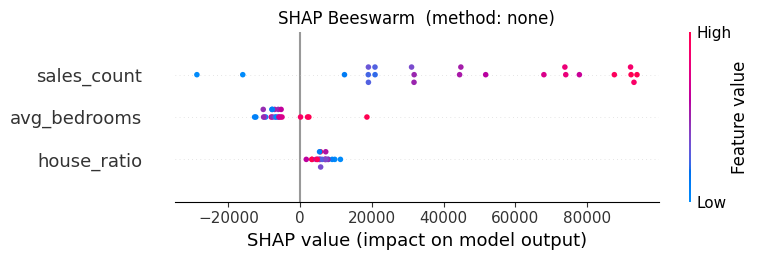


--- Random Forest | outlier method: remove ---
Random Forest RMSE: $59,859.52


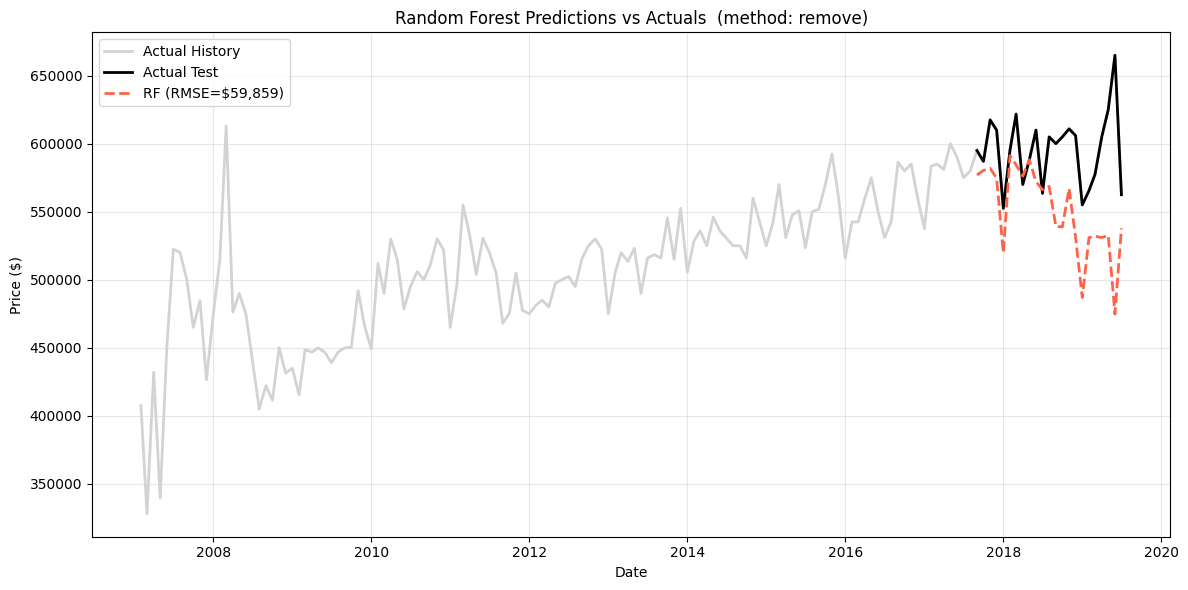

Feature importances:
sales_count     0.7826
avg_bedrooms    0.1130
house_ratio     0.1044
dtype: float64



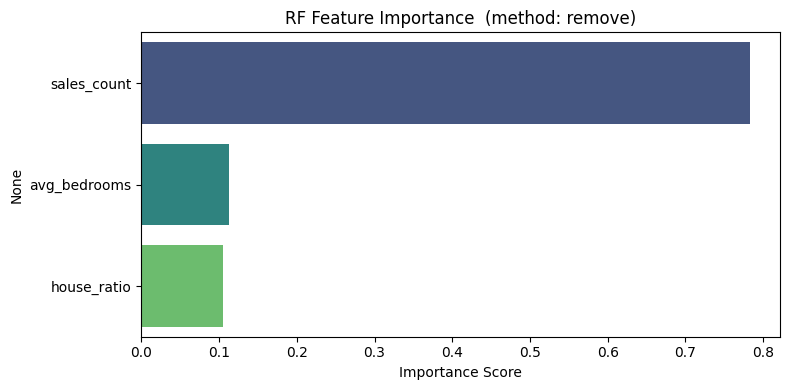

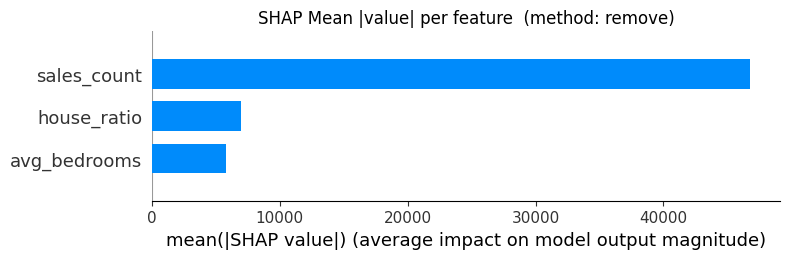

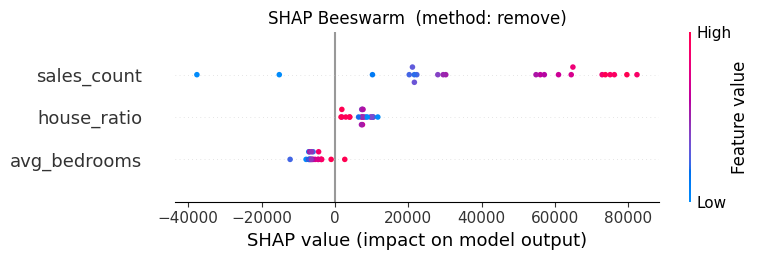


--- Random Forest | outlier method: log_transform ---
Random Forest RMSE: $61,855.97


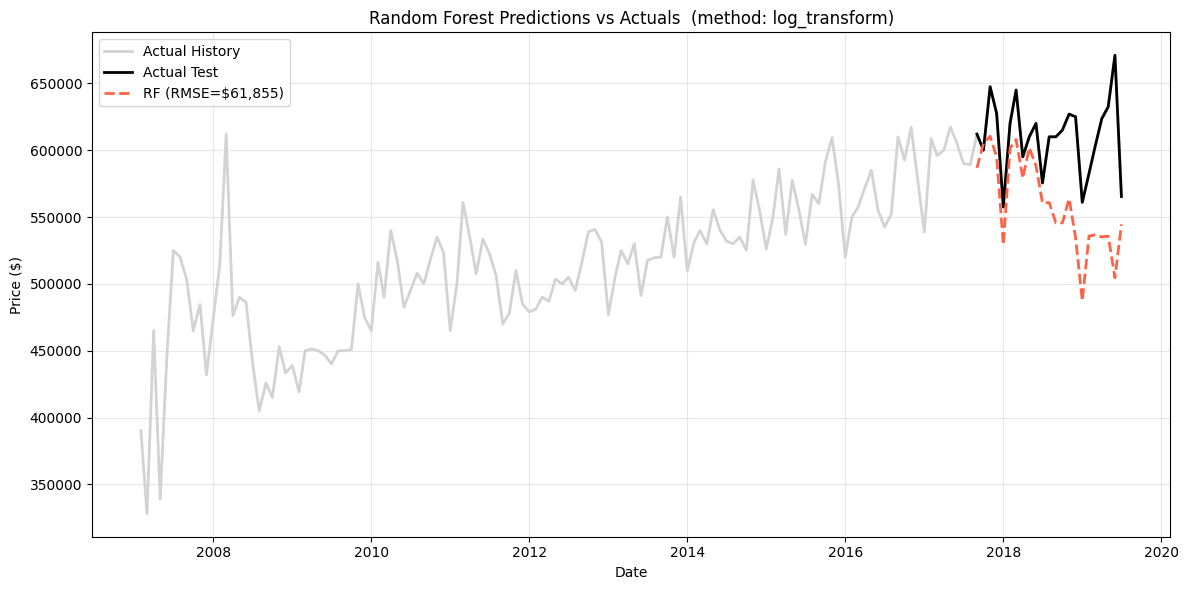

Feature importances:
sales_count     0.7833
avg_bedrooms    0.1315
house_ratio     0.0852
dtype: float64



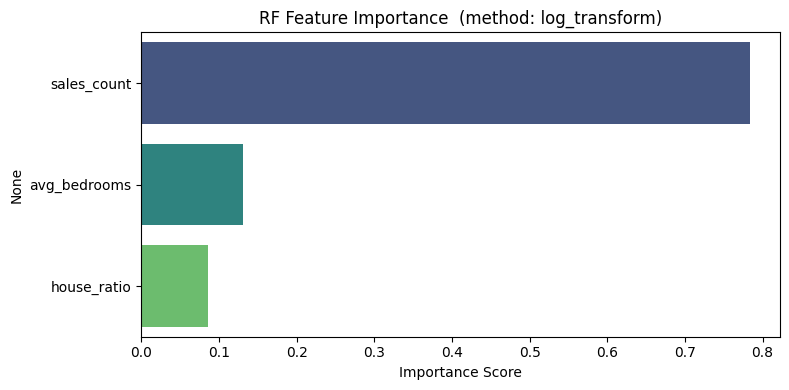

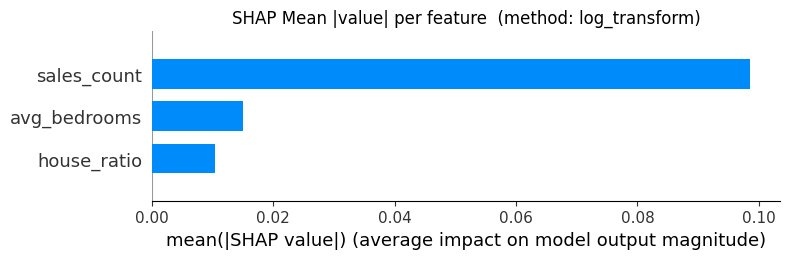

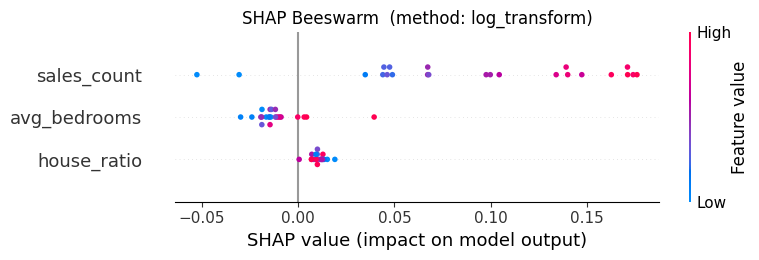

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import shap

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

FEATURES_RF = ['avg_bedrooms', 'house_ratio', 'sales_count']
# FEATURES_RF = ['sales_count']

for type_of_outlier in ['none', 'remove', 'log_transform']:
    print(f"\n--- Random Forest | outlier method: {type_of_outlier} ---")

    # 1. Build pipeline data and add seasonality
    df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)

    # 2. Train / test split
    split_idx = int(len(monthly_df_cleaned) * train_size)
    train = monthly_df_cleaned.iloc[:split_idx]
    test  = monthly_df_cleaned.iloc[split_idx:]

    X_train = train[FEATURES_RF]
    y_train = train['price']
    X_test  = test[FEATURES_RF]
    y_test  = test['price']

    # 3. Fit model
    model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
    model_rf.fit(X_train, y_train)
    predictions = model_rf.predict(X_test)

    # 4. Inverse-transform to dollars
    if type_of_outlier == 'log_transform':
        actual_dollar  = np.exp(y_test.values)
        preds_dollar   = np.exp(predictions)
        history_dollar = np.exp(monthly_df_cleaned['price'].values)
    else:
        actual_dollar  = y_test.values
        preds_dollar   = predictions
        history_dollar = monthly_df_cleaned['price'].values

    # 5. RMSE
    rmse_rf = calculate_rmse(actual_dollar, preds_dollar)
    print(f"Random Forest RMSE: ${rmse_rf:,.2f}")

    # 6. Forecast plot
    full_dates = monthly_df_cleaned.index
    test_dates = test.index

    plt.figure(figsize=(12, 6))
    plt.plot(full_dates, history_dollar, label='Actual History', color='lightgray', linewidth=2)
    plt.plot(test_dates, actual_dollar,  label='Actual Test',    color='black',     linewidth=2)
    plt.plot(test_dates, preds_dollar,   label=f'RF (RMSE=${int(rmse_rf):,})',
             color='tomato', linestyle='--', linewidth=2)
    plt.title(f'Random Forest Predictions vs Actuals  (method: {type_of_outlier})')
    plt.xlabel('Date'); plt.ylabel('Price ($)')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # 7. Feature importance
    importance = pd.Series(model_rf.feature_importances_, index=FEATURES_RF).sort_values(ascending=False)
    print(f"Feature importances:\n{importance.round(4)}\n")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=importance.values, y=importance.index, palette='viridis')
    plt.title(f'RF Feature Importance  (method: {type_of_outlier})')
    plt.xlabel('Importance Score'); plt.tight_layout(); plt.show()

    # 8. SHAP — TreeExplainer is exact and fast for Random Forests
    explainer   = shap.TreeExplainer(model_rf)
    shap_values = explainer.shap_values(X_test)   # shape: (n_test, n_features)

    plt.figure()
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
    plt.title(f'SHAP Mean |value| per feature  (method: {type_of_outlier})')
    plt.tight_layout(); plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)   # beeswarm
    plt.title(f'SHAP Beeswarm  (method: {type_of_outlier})')
    plt.tight_layout(); plt.show()

As expected, applying logarithmic transformation to the data doesn't change the performance of the Random Forest Regressor, as this model is not sensitive to the distribution of the target variable. This is because logarithm is a monotonic transformation, which means it preserves the order of the data points. Therefore, the Random Forest Regressor can still capture the relationships between the features and the target variable effectively, regardless of whether the target variable is log-transformed or not.

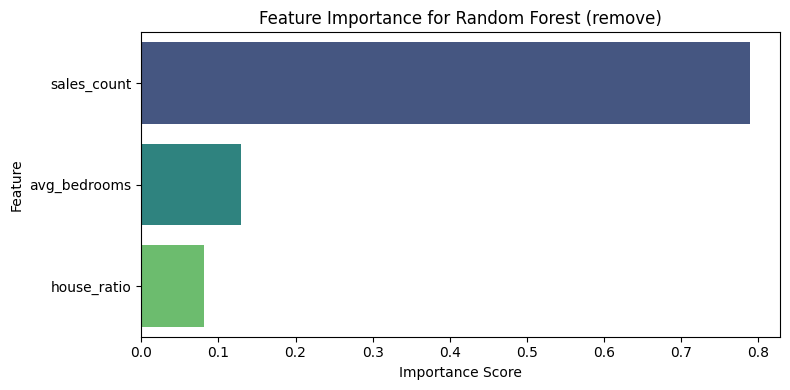

In [24]:
# EXPLANATION OF MOST IMPORTANT FEATURES for random forest regressor

def plot_feature_importance(model, X_train, type_of_outlier):
    feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
    plt.title(f'Feature Importance for Random Forest ({type_of_outlier})')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_feature_importance(model, X_train, type_of_outlier='remove')

Apparently, sales_count is by far the most important feature. This makes sense, as the number of sales in a given month can be a strong indicator of market demand and can significantly influence the median price. A higher sales count may indicate a more active market, which can drive prices up, while a lower sales count may suggest less demand and potentially lower prices.
To further prove this, we can look at the correlation between sales_count and price. If there is a strong positive correlation, it would support the idea that sales_count is a key driver of price. 

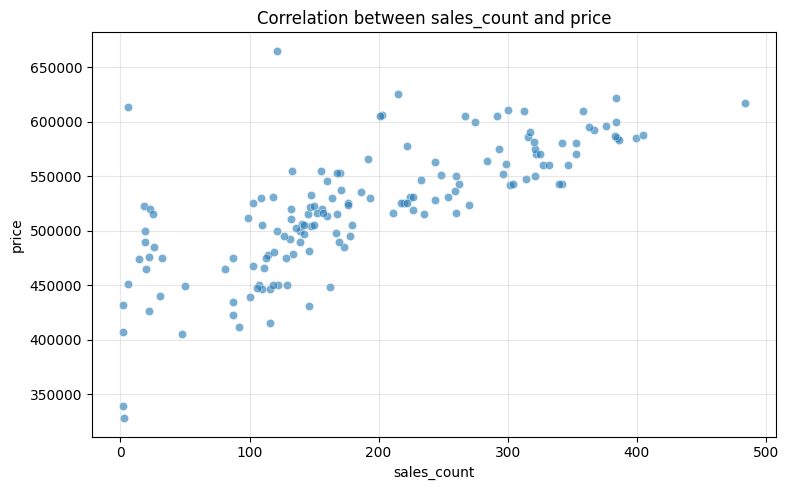

<Figure size 640x480 with 0 Axes>

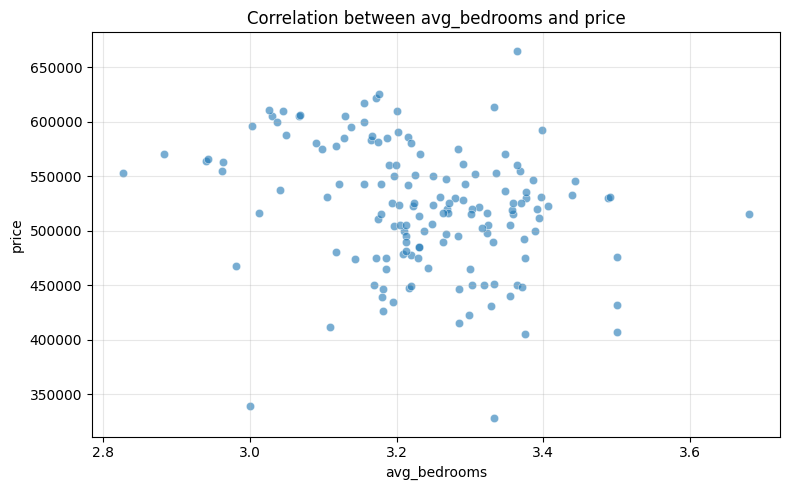

<Figure size 640x480 with 0 Axes>

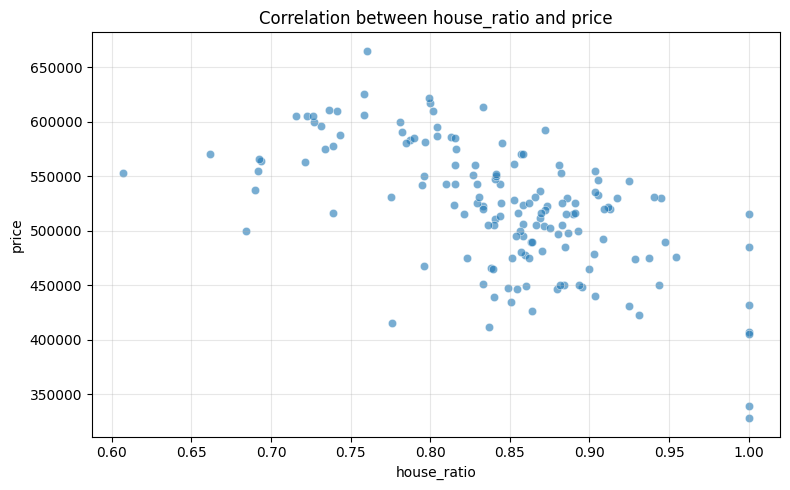

<Figure size 640x480 with 0 Axes>

In [25]:
'''Apparently, sales_count is by far the most important feature. This makes sense, as the number of sales in a given month can be a strong indicator of market demand and can significantly influence the median price. A higher sales count may indicate a more active market, which can drive prices up, while a lower sales count may suggest less demand and potentially lower prices.
To further prove this, we can look at the correlation between sales_count and price. If there is a strong positive correlation, it would support the idea that sales_count is a key driver of price. '''

df, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier='remove', plotting=False)

def plot_correlation(df, feature, target='price'):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df[target], alpha=0.6)
    plt.title(f'Correlation between {feature} and {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    #save image in current directory
    plt.savefig(f'correlation_random_forest_{feature}_{target}.png')

plot_correlation(monthly_df_cleaned, 'sales_count', target='price')
plot_correlation(monthly_df_cleaned, 'avg_bedrooms', target='price')
plot_correlation(monthly_df_cleaned, 'house_ratio', target='price')

### LSTM

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


2026-02-20 15:46:23.138004: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-20 15:46:24.090081: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 15:46:27.073604: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [27]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

def create_sequences(X, y, seq_len=12):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

def run_lstm_multivariate(monthly_df_cleaned, train_size):
    features = ['avg_bedrooms', 'house_ratio', 'sales_count', 'price'] 
    target = 'price'
    price_idx = features.index('price')
    seq_len = 12

    # 1. FIX: Split data BEFORE scaling to prevent data leakage
    split_idx = int(len(monthly_df_cleaned) * train_size)
    train_df = monthly_df_cleaned.iloc[:split_idx]
    test_df = monthly_df_cleaned.iloc[split_idx:]

    # 2. FIX: Fit scalers ONLY on the training data
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(train_df[features])
    scaler_y.fit(train_df[[target]])

    train_scaled = scaler_X.transform(train_df[features])
    test_scaled = scaler_X.transform(test_df[features])

    y_train_scaled = scaler_y.transform(train_df[[target]])
    y_test_scaled = scaler_y.transform(test_df[[target]])

    # ----- Create sequences for Training -----
    X_train, y_train = create_sequences(train_scaled, y_train_scaled, seq_len)

    # ----- Build and Train model -----
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(seq_len, len(features))),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    # 3. FIX: Recursive Forecasting for Testing
    # Start with the last 'seq_len' months of the training data
    current_seq = train_scaled[-seq_len:]
    preds_scaled = []

    for i in range(len(test_scaled)):
        # Predict the next month's price
        current_seq_reshaped = current_seq.reshape(1, seq_len, len(features))
        next_price_scaled = model.predict(current_seq_reshaped, verbose=0)[0][0]
        preds_scaled.append(next_price_scaled)
        
        # Build the next input row:
        # Use the actual future values for exogenous features (bedrooms, sales_count, etc.)
        # But use the PREDICTED value for the price so we aren't cheating
        next_row = test_scaled[i].copy()
        next_row[price_idx] = next_price_scaled
        
        # Shift sequence forward by 1 month, appending the new row
        current_seq = np.append(current_seq[1:], [next_row], axis=0)

    # ----- Inverse Transform & Evaluate -----
    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    
    preds = scaler_y.inverse_transform(preds_scaled)
    y_test_real = scaler_y.inverse_transform(y_test_scaled)

    mse = mean_squared_error(y_test_real, preds)

    return preds, y_test_real, mse

def run_lstm_univariate(monthly_df_cleaned, train_size):
    seq_len = 12

    # 1. Split data FIRST to prevent leakage
    split_index = int(len(monthly_df_cleaned) * train_size)
    train_df = monthly_df_cleaned.iloc[:split_index]
    test_df = monthly_df_cleaned.iloc[split_index:]

    # 2. Fit scaler ONLY on the training data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df[['price']])
    test_scaled = scaler.transform(test_df[['price']])

    # Create training sequences
    X_train, y_train = create_sequences(train_scaled, train_scaled, seq_len)

    # Build and train model
    model = Sequential([
        LSTM(64, input_shape=(seq_len, 1)),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    # 3. Recursive Forecasting for Testing
    # Grab the very last sequence from the training set to kick off predictions
    current_seq = train_scaled[-seq_len:]
    preds_scaled = []

    # Predict one step at a time for the length of the test set
    for _ in range(len(test_scaled)):
        current_seq_reshaped = current_seq.reshape(1, seq_len, 1)
        
        # Predict the next month
        next_pred = model.predict(current_seq_reshaped, verbose=0)[0][0]
        preds_scaled.append(next_pred)
        
        # Shift the sequence: drop the oldest month, append the newly predicted month
        current_seq = np.append(current_seq[1:], [[next_pred]], axis=0)

    # Inverse transform predictions and actuals
    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    preds = scaler.inverse_transform(preds_scaled)
    
    # The actual values are simply the test set prices
    y_test_real = test_df[['price']].values

    mse = mean_squared_error(y_test_real, preds)

    return preds, y_test_real, mse



--- Handling outliers with method: none ---


2026-02-20 15:46:27.856914: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Univariate LSTM RMSE:   $32,716.28
Multivariate LSTM RMSE: $30,874.01


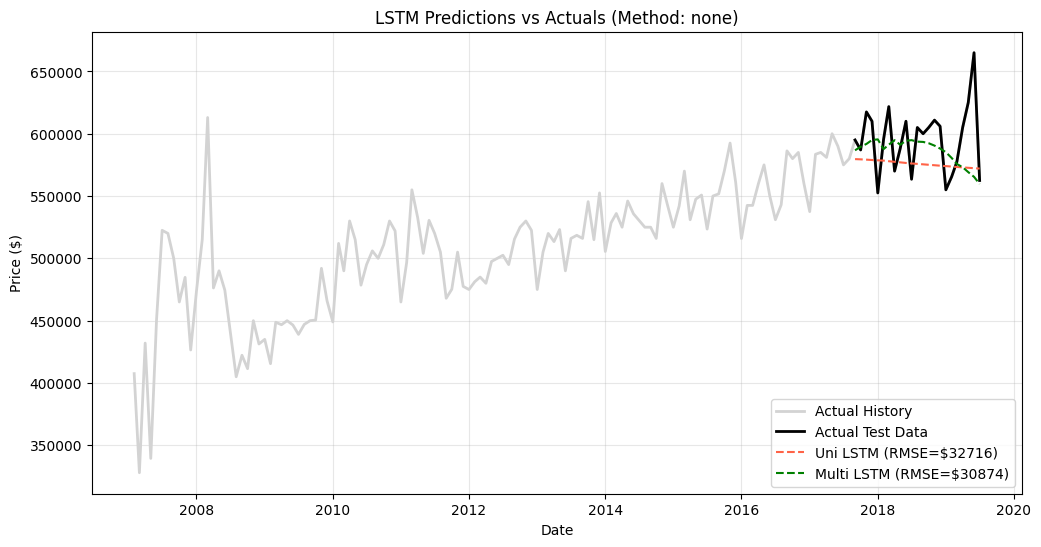


--- Handling outliers with method: remove ---
Univariate LSTM RMSE:   $36,112.46
Multivariate LSTM RMSE: $40,578.53


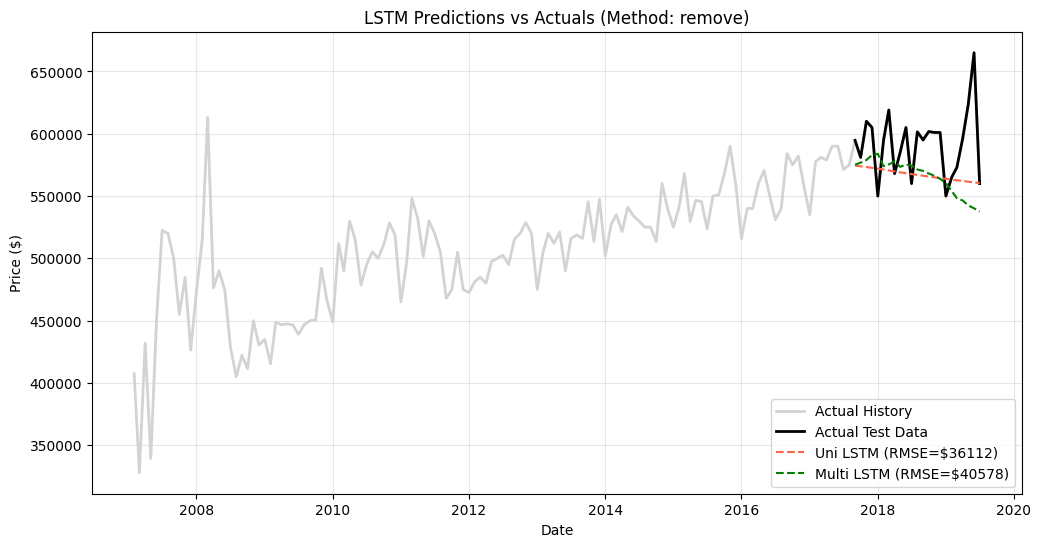


--- Handling outliers with method: log_transform ---
Univariate LSTM RMSE:   $39,231.58
Multivariate LSTM RMSE: $51,584.28


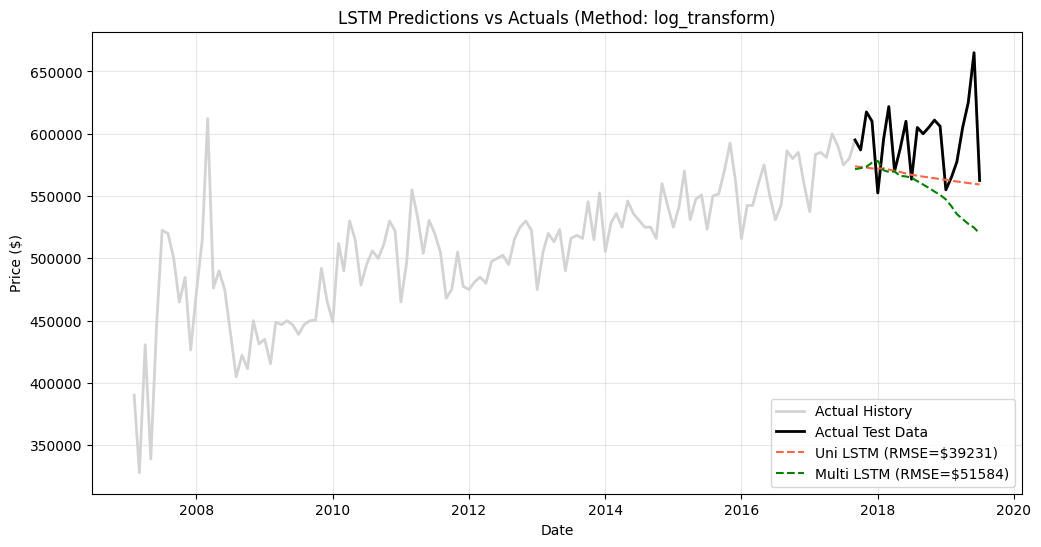

In [28]:
from sklearn.metrics import mean_squared_error
import math

# Function to calculate RMSE in Dollars
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Modified loop to handle inverse transformation and plotting correctly
for type_of_outlier in ['none', 'remove', 'log_transform']: #'power_transform']:
    print(f"\n--- Handling outliers with method: {type_of_outlier} ---")

    # 1. Get Cleaned Data (Note: 'remove' changes the data length and medians!)
    df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)

    # 2. Run Models (These return values in the model's scale: Dollars or Log-Dollars)
    preds_multi, y_multi, _ = run_lstm_multivariate(monthly_df_cleaned, train_size=train_size)
    preds_uni, y_uni, _ = run_lstm_univariate(monthly_df_cleaned, train_size=train_size)

    # 3. Inverse Transform EVERYTHING to Dollars for consistent evaluation
    if type_of_outlier == 'log_transform':
        # Model predicted Log-Price, convert to Price
        actual_dollar = np.exp(y_uni)
        pred_uni_dollar = np.exp(preds_uni)
        pred_multi_dollar = np.exp(preds_multi)
        # Get full history in dollars for context
        history_dollar = np.exp(monthly_df_cleaned['price'].values)
    else:
        # Model predicted Price directly
        actual_dollar = y_uni
        pred_uni_dollar = preds_uni
        pred_multi_dollar = preds_multi
        history_dollar = monthly_df_cleaned['price'].values

    # 4. Calculate RMSE (Interpretable Error in $)
    rmse_uni = calculate_rmse(actual_dollar, pred_uni_dollar)
    rmse_multi = calculate_rmse(actual_dollar, pred_multi_dollar)
    
    print(f"Univariate LSTM RMSE:   ${rmse_uni:,.2f}")
    print(f"Multivariate LSTM RMSE: ${rmse_multi:,.2f}")

    # 5. Plotting (Aligned correctly)
    seq_len = 12
    # The predictions correspond to the END of the dataset (Test set)
    test_start_idx = len(monthly_df_cleaned) - len(actual_dollar)
    
    # Dates for the test set
    test_dates = monthly_df_cleaned.index[test_start_idx:]
    full_dates = monthly_df_cleaned.index

    plt.figure(figsize=(12, 6))
    
    # Plot Full History
    plt.plot(full_dates, history_dollar, label='Actual History', color='lightgray', linewidth=2)
    plt.plot(test_dates, actual_dollar, label='Actual Test Data', color='black', linewidth=2)
    
    # Plot Predictions
    plt.plot(test_dates, pred_uni_dollar, label=f'Uni LSTM (RMSE=${int(rmse_uni)})', color='tomato', linestyle='--')
    plt.plot(test_dates, pred_multi_dollar, label=f'Multi LSTM (RMSE=${int(rmse_multi)})', color='green', linestyle='--')

    plt.title(f'LSTM Predictions vs Actuals (Method: {type_of_outlier})')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# NEXT TOPICS

In [29]:
#TODO: does rmse really mean money? Yes
#TODO: which is the metric that is to be used in this case? rmse, mape, mae, mse?
#rmse, because rmse is used when we want the error to be in the same units as the target variable (in this case, dollars). MAPE and MAE are also common metrics for regression problems, but they have different interpretations. MAPE gives us the average percentage error, which can be useful for understanding relative error, but it can be problematic when actual values are close to zero. MAE gives us the average absolute error, which is easier to interpret than MSE, but it does not penalize larger errors as much as RMSE does. Finally, MSE gives us the average squared error, which can be useful for certain mathematical properties and optimization, but it is less interpretable than RMSE because it is in squared units. In the context of predicting house prices, RMSE is often preferred because it provides an error metric that is directly interpretable in terms of dollars, making it easier for stakeholders to understand the magnitude of the errors in the predictions.

#TODO: why do 'none' and 'remove' have better rmse than log transform?

#TODO: shap explanations for the multivariate LSTM model, to understand how the different features (avg_bedrooms, house_ratio, sales_count) are influencing the predictions of the median price over time.
#TODO: add year/month seasonality to the model, since we know that house prices can be influenced by seasonality (e.g., higher prices in spring/summer). We can add month and year as additional features to the multivariate LSTM model, and then analyze their importance using SHAP values to see how they contribute to the predictions.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


100%|██████████| 20/20 [00:02<00:00,  6.78it/s]


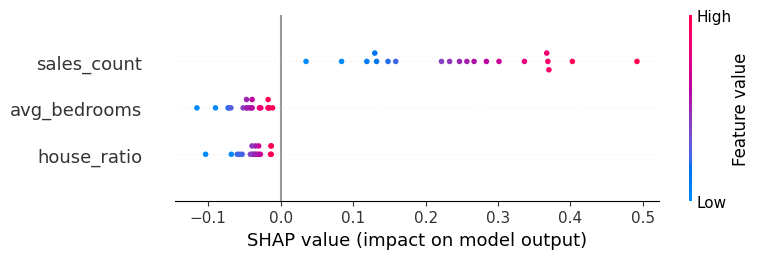

In [30]:
import shap

def run_lstm_multivariate(monthly_df_cleaned, train_size):

    '''
    This function runs a multivariate LSTM model using the 'avg_bedrooms', 'house_ratio', and 'sales_count' features from monthly_df_cleaned to predict the 'price' target.
    It scales the features and target, creates sequences, trains the LSTM, and returns predictions, actual values, and MSE.
    Multivariate means we are using multiple features (avg_bedrooms, house_ratio, sales_count) to predict the price, which allows the model to learn from the relationships between these features and the target variable.
    '''

    features = ['avg_bedrooms', 'house_ratio', 'sales_count']
    target = 'price'

    # ----- Scale data -----
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    #example of what MinMaxScaler does: if we have a feature that ranges from 0 to 100, MinMaxScaler will transform it to a range of 0 to 1 by applying the formula: X_scaled = (X - X_min) / (X_max - X_min). This means that the minimum value of the feature will be transformed to 0, the maximum value will be transformed to 1, and all other values will be scaled proportionally within this range. This is important for LSTM models because it helps to ensure that all features are on a similar scale, which can improve the convergence and performance of the model.

    X_scaled = scaler_X.fit_transform(monthly_df_cleaned[features])
    y_scaled = scaler_y.fit_transform(monthly_df_cleaned[[target]])

    # ----- Create sequences -----
    seq_len = 12
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_len)

    split_idx = int(len(X_seq) * train_size)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

    # ----- Build model -----
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(seq_len, X_train.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    # ----- Predict -----
    preds_scaled = model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)

    mse = mean_squared_error(y_test_real, preds)

    return model, X_train, X_test, preds, y_test_real, mse

# 1. Define the features we used
features_list = ['avg_bedrooms', 'house_ratio', 'sales_count']

# 2. Train the model with these features
# Note: We capture the model and data from the updated function return
model_multi, X_train_multi, X_test_multi, _, _, _ = run_lstm_multivariate(monthly_df_cleaned, train_size)

# 3. Use SHAP KernelExplainer (model-agnostic, works well with TF 2.x)
# We summarize the training data (e.g., first 50 samples) as background,
# using only the latest time step in each sequence.
X_train_last = X_train_multi[:50, -1, :]  # (background_samples, features)
X_test_last = X_test_multi[:20, -1, :]    # (samples_to_explain, features)

# Helper prediction function that maps 2D feature input to the LSTM's 3D input
seq_len_local = X_train_multi.shape[1]

def lstm_predict_last(x):
    # x has shape (n_samples, n_features)
    # Repeat the last-timestep features across the full sequence length
    x_seq = np.tile(x[:, np.newaxis, :], (1, seq_len_local, 1))
    # Return 1D array of predictions for KernelExplainer
    return model_multi.predict(x_seq, verbose=0).ravel()

explainer = shap.KernelExplainer(lstm_predict_last, X_train_last)

# 4. Calculate SHAP values for the test set (may take a little time)
shap_values = explainer.shap_values(X_test_last, nsamples=100)

# 5. Visualize feature importance for the latest time step
shap.initjs()  # Required if running in Jupyter
shap.summary_plot(
    shap_values, 
    X_test_last, 
    feature_names=features_list,
    title="Feature Importance at Prediction Time (t)"
)

In [17]:
%pip install statsmodels pmdarima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

Note: you may need to restart the kernel to use updated packages.


In [19]:
df = pd.read_csv('raw_sales.csv')
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df = imputer_pipeline(df)

# Use the same outlier strategy as the tree/LSTM runs; price is log if you pick log_transform
outlier_mode = 'remove'
df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=outlier_mode, plotting=False)

monthly_df = monthly_df_cleaned.asfreq('MS')

train_size = int(len(monthly_df) * train_size)
train = monthly_df.iloc[:train_size]
test = monthly_df.iloc[train_size:]

y_train = train['price']
y_test  = test['price']
X_train = train[['avg_bedrooms', 'house_ratio', 'sales_count']]
X_test  = test[['avg_bedrooms', 'house_ratio', 'sales_count']]

print(f"Train: {len(train)} | Test: {len(test)}")
print("Train range:", train.index.min(), "→", train.index.max())
print("Test range:", test.index.min(), "→", test.index.max())

Train: 127 | Test: 23
Train range: 2007-02-01 00:00:00 → 2017-08-01 00:00:00
Test range: 2017-09-01 00:00:00 → 2019-07-01 00:00:00


In [20]:
auto_model = auto_arima(
    y=y_train,
    exogenous=X_train,
    seasonal=True,
    m=12,                       
    trace=True,                  
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    max_order=None,
    information_criterion='aic'  
)


print("Best model order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.40 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2989.463, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2969.163, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2975.188, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2987.674, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2969.302, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2971.150, Time=0.20 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2969.993, Time=0.15 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2969.132, Time=0.07 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=2971.034, Time=0.39 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=2971.419, Time=0.84 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=2991.329, Time=0.07 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AIC=2969.483, Time=0.08 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=2968.439, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[12]

In [21]:
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  127
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood               -1257.801
Date:                            Fri, 20 Feb 2026   AIC                           2529.603
Time:                                    15:56:38   BIC                           2548.632
Sample:                                02-01-2007   HQIC                          2537.324
                                     - 08-01-2017                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms  1.207e+05   4.81e+04      2.509      0.012    2.64e+04    2.15e+05
house_ratio  -1.405e+05   9.0

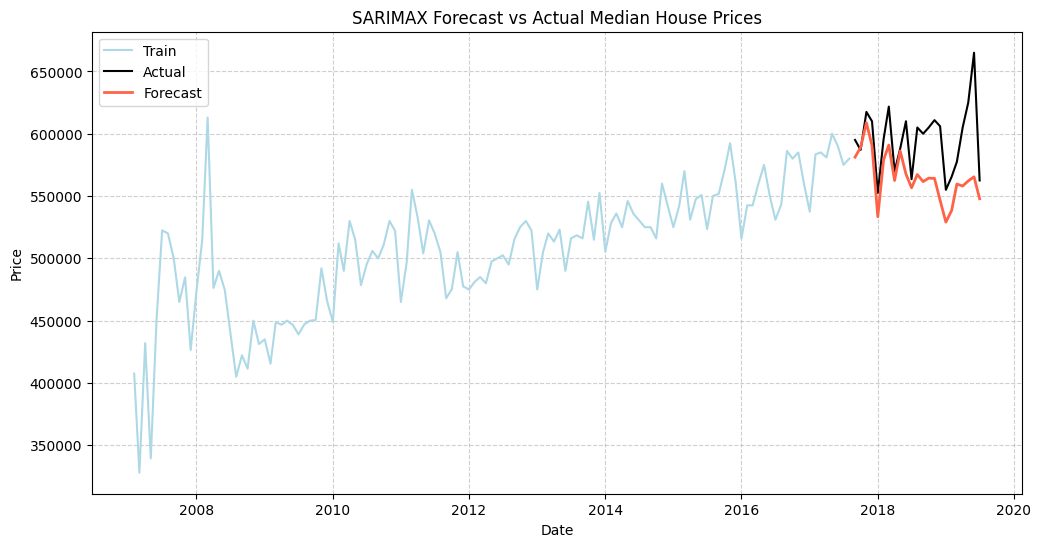

In [22]:
forecast = sarimax_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Train', color='lightblue')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, forecast, label='Forecast', color='tomato', linewidth=2)
plt.title("SARIMAX Forecast vs Actual Median House Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()